In [1]:
import pandas as pd
df=pd.read_csv("houseprice.csv")
print(df.head())

   area  bedrooms  bathrooms  age   location_score    price
0   650         1          1    20               4  1850000
1   720         2          1    15               5   215000
2   800         2          1    18               6  2400000
3   850         2          2    10               6  2650000
4   900         2          2    12               7  2900000


In [2]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   area            10 non-null     int64
 1   bedrooms        10 non-null     int64
 2   bathrooms       10 non-null     int64
 3   age             10 non-null     int64
 4   location_score  10 non-null     int64
 5   price           10 non-null     int64
dtypes: int64(6)
memory usage: 608.0 bytes
None
              area   bedrooms  bathrooms      age   location_score  \
count    10.000000  10.000000  10.000000  10.00000       10.000000   
mean    917.000000   2.400000   1.800000  10.70000        6.400000   
std     163.981706   0.699206   0.632456   5.47824        1.264911   
min     650.000000   1.000000   1.000000   4.00000        4.000000   
25%     812.500000   2.000000   1.250000   6.50000        6.000000   
50%     925.000000   2.500000   2.000000   9.50000        6.500000   
75%    1037.50000

In [3]:
X=df[["area", "bedrooms", "bathrooms", "age ", "location_score"]]
y=df["price"]
print(X.shape)
print(y.shape)

(10, 5)
(10,)


In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(
X,y, test_size=0.2, random_state=42
)
print("Train size:",X_train.shape[0])
print("Test size:",X_test.shape[0])

Train size: 8
Test size: 2


In [11]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train, y_train)
print("Coefficients:",model.coef_)
print("Intercept:",model.intercept_)

Coefficients: [   6319.21487603 -244576.44628099 -232024.79338843  -19989.66942149
  -74018.59504132]
Intercept: -1100103.3057851251


In [12]:
y_pred=model.predict(X_test)
print(y_pred[:5])
print(y_test.values[:5])

[4015185.95041322 2058615.70247934]
[3750000  215000]


In [13]:
from sklearn.metrics import(
mean_absolute_error,mean_squared_error,r2_score
)
import numpy as np
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("MAE:",mae,"RMSE:",rmse,"R2:",r2)

MAE: 1054400.8264462806 RMSE: 1317050.1977382924 R2: 0.4447535240882827


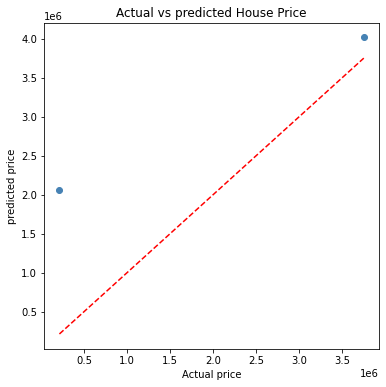

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred,color="steelblue")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],"r--")
plt.xlabel("Actual price")
plt.ylabel("predicted price")
plt.title("Actual vs predicted House Price")
plt.show()

In [18]:
X2=df[["area", "bedrooms", "bathrooms", "location_score"]]
y2=df["price"]
X2_train, X2_test, y2_train, y2_test=train_test_split(
X2,y2,test_size=0.2,random_state=42
)
mode12=LinearRegression()
mode12.fit(X2_train,y2_train)
pred2=mode12.predict(X2_test)
print("R2(3 features):",r2_score(y2_test,pred2))
print("R2(5 features):",r2)


R2(3 features): 0.46279421295010503
R2(5 features): 0.4447535240882827
